# Transformer model for when prediction (1-hour context only)

This notebook trains transformer regressors for the time-to-event (“when”) task. It intentionally uses only the 1-hour event window and performs no window-size or hyperparameter search.

The event sequence comes from the row-aligned 1-hour “where” dataset, which contains the categorical event records used by the existing transformer. The regression target and fold assignments come from the matching 1-hour “when” dataset.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

DATA_DIR = Path("output")
OUTPUT_DIR = Path("model_outputs")
MODEL_OUTPUT_DIR = OUTPUT_DIR / "transformer_when"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Fixed by design: this notebook does not search over window sizes.
WINDOW_HOURS = 1
WHEN_DATASET_PATH = DATA_DIR / "dataset_winsize1h_when.csv"
SEQUENCE_DATASET_PATH = DATA_DIR / "dataset_winsize1h_where.csv"

RANDOM_STATE = 42
SECONDS_PER_HOUR = 60 * 60
TRAIN_FOLDS = [0, 1, 2, 3, 4]
TEST_FOLD = -1
REGRESSION_TARGET = "label_time_to_event_seconds"
REGRESSION_SUMMARY_FILENAME = "regression_summary_Transformer.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed()
print(f"Using {DEVICE = }")
print(f"Using fixed {WINDOW_HOURS = }")

Using DEVICE = device(type='cuda')
Using fixed WINDOW_HOURS = 1


## Load and align the 1-hour data

The dataset-generation notebook creates the “when” and “where” files from the same ordered samples and assigns the same folds. The checks below prevent accidental training if those files are no longer aligned.

In [2]:
where_df = pd.read_csv(
    SEQUENCE_DATASET_PATH,
    dtype={"fold_id": "int64"},
    converters={"window": json.loads, "label": json.loads},
)
when_df = pd.read_csv(
    WHEN_DATASET_PATH,
    dtype={"fold_id": "int64"},
)

if len(where_df) != len(when_df):
    raise ValueError(
        "The 1-hour sequence and when datasets have different row counts: "
        f"{len(where_df)} != {len(when_df)}"
    )
if not np.array_equal(
    where_df["fold_id"].to_numpy(),
    when_df["fold_id"].to_numpy(),
):
    raise ValueError("Fold IDs are not row-aligned between the 1-hour datasets.")
if not np.array_equal(
    where_df["is_bg"].to_numpy(),
    when_df["is_bg"].to_numpy(),
):
    raise ValueError("Background labels are not row-aligned between the datasets.")

data_df = where_df.copy()
data_df["target_seconds"] = when_df[REGRESSION_TARGET].astype(float)
data_df = data_df.loc[~when_df["is_bg"]].reset_index(drop=True)

if data_df["target_seconds"].isna().any():
    raise ValueError("The filtered 1-hour dataset contains missing time targets.")

print(f"Sequence dataset: {SEQUENCE_DATASET_PATH}")
print(f"When dataset:    {WHEN_DATASET_PATH}")
print(f"Usable samples:   {len(data_df):,}")
display(data_df.groupby("fold_id").size().rename("samples").to_frame())
display(data_df["target_seconds"].describe().to_frame())

Sequence dataset: output/dataset_winsize1h_where.csv
When dataset:    output/dataset_winsize1h_when.csv
Usable samples:   3,711


,samples
fold_id,
-1,744
0,594
1,587
2,609
3,581
4,596


,target_seconds
count,3711.000000
mean,2177.300189
std,2144.393578
min,0.000000
25%,300.000000
50%,1500.000000
75%,3600.000000
max,7506.000000


In [3]:
OUTAGE_TYPE_TO_ID = {"Planned": 0, "Auto": 1}


class WhenOutageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        window = row["window"]
        return {
            "outage_type": torch.tensor(
                [OUTAGE_TYPE_TO_ID[event["outage_type"]] for event in window],
                dtype=torch.long,
            ),
            "from_zone_indices": torch.tensor(
                [event["from_zone_index"] for event in window],
                dtype=torch.long,
            ),
            "to_zone_indices": torch.tensor(
                [event["to_zone_index"] for event in window],
                dtype=torch.long,
            ),
            "time_interval_index": torch.tensor(
                [event["time_interval_index"] for event in window],
                dtype=torch.long,
            ),
            # Training in hours keeps the regression scale manageable.
            "target_hours": torch.tensor(
                row["target_seconds"] / SECONDS_PER_HOUR,
                dtype=torch.float32,
            ),
        }


def collate_when_samples(samples):
    lengths = torch.tensor(
        [len(sample["outage_type"]) for sample in samples],
        dtype=torch.long,
    )
    max_length = int(lengths.max())
    padding_mask = torch.arange(max_length).unsqueeze(0) >= lengths.unsqueeze(1)
    return {
        "outage_type": pad_sequence(
            [sample["outage_type"] for sample in samples],
            batch_first=True,
            padding_value=0,
        ),
        "from_zone_indices": pad_sequence(
            [sample["from_zone_indices"] for sample in samples],
            batch_first=True,
            padding_value=0,
        ),
        "to_zone_indices": pad_sequence(
            [sample["to_zone_indices"] for sample in samples],
            batch_first=True,
            padding_value=0,
        ),
        "time_interval_index": pad_sequence(
            [sample["time_interval_index"] for sample in samples],
            batch_first=True,
            padding_value=0,
        ),
        "lengths": lengths,
        "padding_mask": padding_mask,
        "target_hours": torch.stack([sample["target_hours"] for sample in samples]),
    }


train_when_dataset = WhenOutageDataset(data_df[data_df["fold_id"].isin(TRAIN_FOLDS)])
test_when_dataset = WhenOutageDataset(data_df[data_df["fold_id"] == TEST_FOLD])

all_events = [event for window in data_df["window"] for event in window]
num_zones = (
    max(max(event["from_zone_index"], event["to_zone_index"]) for event in all_events)
    + 1
)
num_time_intervals = max(event["time_interval_index"] for event in all_events) + 1
num_outage_types = len(OUTAGE_TYPE_TO_ID)

print(f"{len(train_when_dataset) = :,}")
print(f"{len(test_when_dataset) = :,}")
print(f"{num_zones = }")
print(f"{num_time_intervals = }")

len(train_when_dataset) = 2,967
len(test_when_dataset) = 744
num_zones = 24
num_time_intervals = 3


## Transformer definition

The model follows the event-embedding and transformer-encoder design in the “where” notebook. The only task-specific change is the scalar regression head. Mini-batches use a padding mask, and the representation of the last real event is used for prediction.

In [ ]:
MODEL_SCALE = 1

ZONE_EMBEDDING_DIM = int(64 * MODEL_SCALE)
OUTAGE_TYPE_EMBEDDING_DIM = int(32 * MODEL_SCALE)
TIME_INTERVAL_EMBEDDING_DIM = int(32 * MODEL_SCALE)
TRANSFORMER_DIM = int(256 * MODEL_SCALE)

DROPOUT = 0.15
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 64
BATCH_SIZE = 32

In [5]:
class WhenTransformer(nn.Module):
    """Transformer regressor over the preceding outage-event sequence."""

    def __init__(
        self,
        num_zones,
        num_outage_types,
        num_time_intervals,
        zone_embedding_dim=ZONE_EMBEDDING_DIM,
        outage_type_embedding_dim=OUTAGE_TYPE_EMBEDDING_DIM,
        time_interval_embedding_dim=TIME_INTERVAL_EMBEDDING_DIM,
        transformer_dim=TRANSFORMER_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.zone_embedding = nn.Embedding(num_zones, zone_embedding_dim)
        self.outage_type_embedding = nn.Embedding(
            num_outage_types, outage_type_embedding_dim
        )
        self.time_interval_embedding = nn.Embedding(
            num_time_intervals, time_interval_embedding_dim
        )
        self.input_fc = nn.Linear(
            2 * zone_embedding_dim
            + outage_type_embedding_dim
            + time_interval_embedding_dim,
            transformer_dim,
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=transformer_dim // 64,
            dim_feedforward=transformer_dim * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.projection = nn.Linear(transformer_dim, 1)

    def forward(
        self,
        from_zone_indices,
        to_zone_indices,
        outage_type,
        time_interval_index,
        lengths,
        padding_mask,
    ):
        x = torch.cat(
            [
                self.zone_embedding(from_zone_indices),
                self.zone_embedding(to_zone_indices),
                self.outage_type_embedding(outage_type),
                self.time_interval_embedding(time_interval_index),
            ],
            dim=-1,
        )
        x = self.input_fc(x)
        x = self.transformer_encoder(x, src_key_padding_mask=padding_mask)
        last_event_index = lengths - 1
        pooled = x[
            torch.arange(x.shape[0], device=x.device),
            last_event_index,
        ]
        return self.projection(pooled).squeeze(-1)

## Leading and lagging penalties

This standalone settings cell controls the asymmetric objective. A leading prediction estimates an event sooner than it occurs (prediction < target); a lagging prediction estimates it later than it occurs (prediction > target).

In [6]:
LEADING_PREDICTION_PENALTY = 1.0
LAGGING_PREDICTION_PENALTY = 3.0

In [7]:
def make_data_loaders(seed=RANDOM_STATE):
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(
        train_when_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_when_samples,
        generator=generator,
    )
    test_loader = DataLoader(
        test_when_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_when_samples,
    )
    return train_loader, test_loader


def batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}


def predict_batch(model, batch):
    return model(
        batch["from_zone_indices"],
        batch["to_zone_indices"],
        batch["outage_type"],
        batch["time_interval_index"],
        batch["lengths"],
        batch["padding_mask"],
    )


def mae_loss_hours(prediction, target):
    return torch.abs(prediction - target).mean()


def asymmetric_mae_loss_hours(prediction, target):
    residual = prediction - target
    weights = torch.where(
        residual < 0,
        torch.as_tensor(
            LEADING_PREDICTION_PENALTY,
            dtype=prediction.dtype,
            device=prediction.device,
        ),
        torch.as_tensor(
            LAGGING_PREDICTION_PENALTY,
            dtype=prediction.dtype,
            device=prediction.device,
        ),
    )
    return (weights * residual.abs()).mean()


def run_epoch(model, data_loader, loss_fn, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    objective_sum = 0.0
    absolute_error_sum = 0.0
    sample_count = 0

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for batch in data_loader:
            batch = batch_to_device(batch, DEVICE)
            if is_training:
                optimizer.zero_grad(set_to_none=True)

            prediction = predict_batch(model, batch)
            target = batch["target_hours"]
            loss = loss_fn(prediction, target)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = target.shape[0]
            objective_sum += loss.item() * batch_size
            absolute_error_sum += torch.abs(prediction - target).sum().item()
            sample_count += batch_size

    mae_hours = absolute_error_sum / sample_count
    return {
        "objective": objective_sum / sample_count,
        "mae_hours": mae_hours,
        "mae_seconds": mae_hours * SECONDS_PER_HOUR,
    }


def train_when_model(loss_fn, model_label):
    set_seed()
    model = WhenTransformer(
        num_zones=num_zones,
        num_outage_types=num_outage_types,
        num_time_intervals=num_time_intervals,
    ).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    train_loader, test_loader = make_data_loaders()
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        train_metrics = run_epoch(model, train_loader, loss_fn, optimizer=optimizer)
        test_metrics = run_epoch(model, test_loader, loss_fn)
        history.append(
            {
                "epoch": epoch,
                "train_objective": train_metrics["objective"],
                "test_objective": test_metrics["objective"],
                "train_mae_seconds": train_metrics["mae_seconds"],
                "test_mae_seconds": test_metrics["mae_seconds"],
            }
        )
        print(
            f"{model_label} | epoch {epoch:03d} | "
            f"train MAE={train_metrics['mae_seconds']:.3f}s | "
            f"test MAE={test_metrics['mae_seconds']:.3f}s | "
            f"train objective={train_metrics['objective']:.6f} | "
            f"test objective={test_metrics['objective']:.6f}"
        )

    return model, pd.DataFrame(history)


def collect_predictions(model, dataset):
    data_loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_when_samples,
    )
    true_hours = []
    predicted_hours = []

    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            batch = batch_to_device(batch, DEVICE)
            prediction = predict_batch(model, batch)
            true_hours.append(batch["target_hours"].cpu().numpy())
            predicted_hours.append(prediction.cpu().numpy())

    y_true_seconds = np.concatenate(true_hours) * SECONDS_PER_HOUR
    y_pred_seconds = np.concatenate(predicted_hours) * SECONDS_PER_HOUR
    signed_error = y_true_seconds - y_pred_seconds
    absolute_error = np.abs(signed_error)
    leading_mask = signed_error > 0
    lagging_mask = signed_error < 0
    asymmetric_weighted_error = np.where(
        leading_mask,
        LEADING_PREDICTION_PENALTY * absolute_error,
        np.where(
            lagging_mask,
            LAGGING_PREDICTION_PENALTY * absolute_error,
            0.0,
        ),
    )
    return pd.DataFrame(
        {
            "y_true": y_true_seconds,
            "y_pred": y_pred_seconds,
            "signed_error": signed_error,
            "absolute_error": absolute_error,
            "asymmetric_weighted_absolute_error": asymmetric_weighted_error,
            "is_leading_prediction": leading_mask,
            "is_lagging_prediction": lagging_mask,
        }
    )


def regression_metrics(prediction_df):
    absolute_errors = prediction_df["absolute_error"]
    lower_quartile = absolute_errors.quantile(0.25)
    upper_quartile = absolute_errors.quantile(0.75)
    middle_errors = absolute_errors[
        absolute_errors.between(lower_quartile, upper_quartile, inclusive="both")
    ]
    return {
        "mae": float(absolute_errors.mean()),
        "middle_50_mae": float(middle_errors.mean()),
        "rmse": float(
            mean_squared_error(prediction_df["y_true"], prediction_df["y_pred"]) ** 0.5
        ),
        "r2": float(r2_score(prediction_df["y_true"], prediction_df["y_pred"])),
        "asymmetric_penalized_mae": float(
            prediction_df["asymmetric_weighted_absolute_error"].mean()
        ),
        "leading_prediction_rate": float(prediction_df["is_leading_prediction"].mean()),
        "lagging_prediction_rate": float(prediction_df["is_lagging_prediction"].mean()),
        "leading_prediction_penalty": LEADING_PREDICTION_PENALTY,
        "lagging_prediction_penalty": LAGGING_PREDICTION_PENALTY,
    }


def save_checkpoint(model, training_history, model_name, loss_name):
    checkpoint_path = MODEL_OUTPUT_DIR / f"{model_name}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_name": model_name,
            "loss_name": loss_name,
            "window_hours": WINDOW_HOURS,
            "num_zones": num_zones,
            "num_outage_types": num_outage_types,
            "num_time_intervals": num_time_intervals,
            "zone_embedding_dim": ZONE_EMBEDDING_DIM,
            "outage_type_embedding_dim": OUTAGE_TYPE_EMBEDDING_DIM,
            "time_interval_embedding_dim": TIME_INTERVAL_EMBEDDING_DIM,
            "transformer_dim": TRANSFORMER_DIM,
            "dropout": DROPOUT,
            "outage_type_to_id": OUTAGE_TYPE_TO_ID,
            "training_history": training_history.to_dict(orient="records"),
            "leading_prediction_penalty": LEADING_PREDICTION_PENALTY,
            "lagging_prediction_penalty": LAGGING_PREDICTION_PENALTY,
        },
        checkpoint_path,
    )
    print(f"Saved checkpoint to {checkpoint_path}")
    return checkpoint_path

## Baseline MAE model

In [8]:
baseline_model, baseline_history = train_when_model(
    mae_loss_hours,
    model_label="Baseline MAE",
)
baseline_predictions = collect_predictions(baseline_model, test_when_dataset)
baseline_metrics = regression_metrics(baseline_predictions)

baseline_checkpoint_path = save_checkpoint(
    baseline_model,
    baseline_history,
    model_name="when_transformer_mae_1h",
    loss_name="mae",
)
baseline_history.to_csv(MODEL_OUTPUT_DIR / "baseline_training_history.csv", index=False)
baseline_predictions.to_csv(
    MODEL_OUTPUT_DIR / "baseline_test_predictions.csv", index=False
)
(MODEL_OUTPUT_DIR / "baseline_metrics.json").write_text(
    json.dumps(baseline_metrics, indent=4)
)

baseline_summary = pd.DataFrame([{"model": "Baseline MAE", **baseline_metrics}])
display(baseline_summary)

print(f"Test MAE: {baseline_metrics['mae']:.6f} seconds")
print(
    "Middle-50% MAE: "
    f"{baseline_metrics['middle_50_mae']:.6f} seconds "
    f"({baseline_metrics['middle_50_mae'] / 60:.6f} minutes)"
)
print(f"Test RMSE: {baseline_metrics['rmse']:.6f} seconds")
print(f"Test R2: {baseline_metrics['r2']:.6f}")
print("Leading prediction rate: " f"{baseline_metrics['leading_prediction_rate']:.6%}")
print("Lagging prediction rate: " f"{baseline_metrics['lagging_prediction_rate']:.6%}")

/home/aj/venv/lib/python3.14/site-packages/torch/autograd/graph.py:882: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/aj/venv/lib/python3.14/site-packages/torch/nn/modules/transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Baseline MAE | epoch 001 | train MAE=1899.001s | test MAE=1722.744s | train objective=0.527500 | test objective=0.478540
Baseline MAE | epoch 002 | train MAE=1757.602s | test MAE=1646.014s | train objective=0.488223 | test objective=0.457226
Baseline MAE | epoch 003 | train MAE=1742.736s | test MAE=1694.751s | train objective=0.484093 | test objective=0.470764
Baseline MAE | epoch 004 | train MAE=1731.140s | test MAE=1704.878s | train objective=0.480872 | test objective=0.473577
Baseline MAE | epoch 005 | train MAE=1710.056s | test MAE=1676.384s | train objective=0.475015 | test objective=0.465662
Baseline MAE | epoch 006 | train MAE=1728.316s | test MAE=1667.861s | train objective=0.480088 | test objective=0.463295
Baseline MAE | epoch 007 | train MAE=1695.502s | test MAE=1647.067s | train objective=0.470973 | test objective=0.457519
Baseline MAE | epoch 008 | train MAE=1683.339s | test MAE=1630.268s | train objective=0.467594 | test objective=0.452852
Baseline MAE | epoch 009 | train

,model,mae,middle_50_mae,rmse,r2,asymmetric_penalized_mae,leading_prediction_rate,lagging_prediction_rate,leading_prediction_penalty,lagging_prediction_penalty
0,Baseline MAE,1714.912109,1350.931641,2272.935437,-0.170619,2949.378418,0.494624,0.505376,1.0,3.0


Test MAE: 1714.912109 seconds
Middle-50% MAE: 1350.931641 seconds (22.515527 minutes)
Test RMSE: 2272.935437 seconds
Test R2: -0.170619
Leading prediction rate: 49.462366%
Lagging prediction rate: 50.537634%


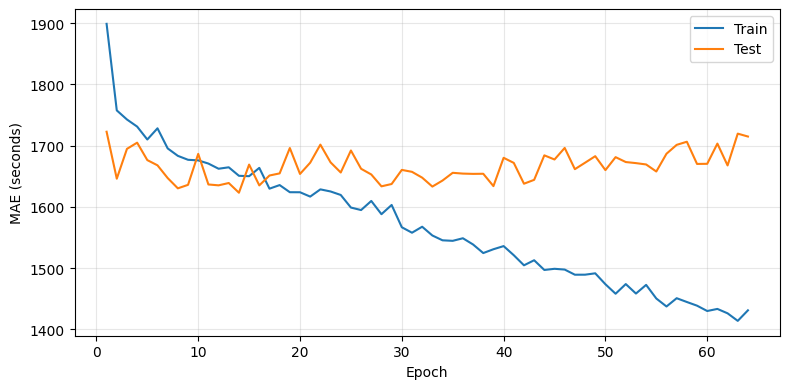

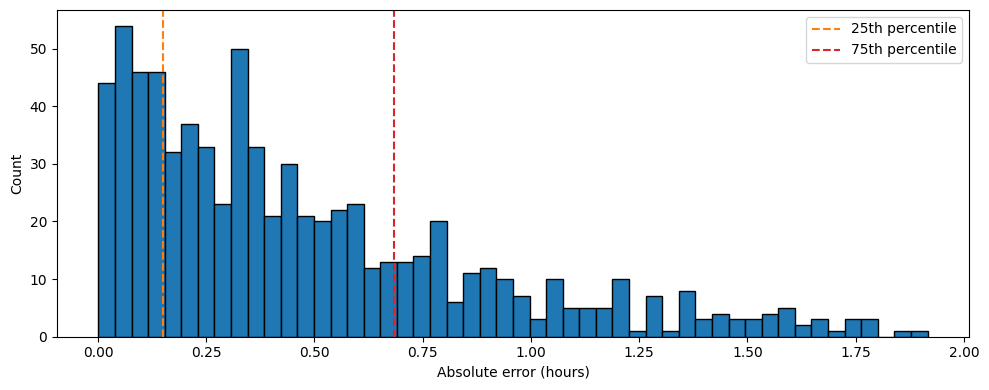

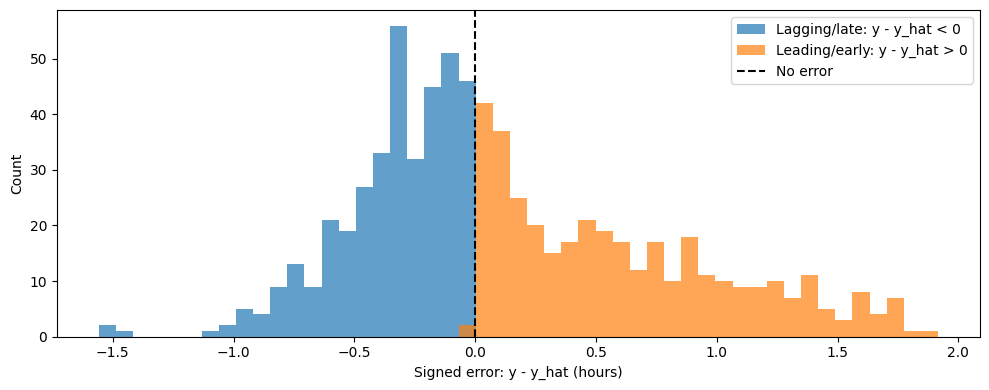

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(
    baseline_history["epoch"],
    baseline_history["train_mae_seconds"],
    label="Train",
)
plt.plot(
    baseline_history["epoch"],
    baseline_history["test_mae_seconds"],
    label="Test",
)
plt.xlabel("Epoch")
plt.ylabel("MAE (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / "baseline_training_mae.pdf", dpi=300)
plt.show()

absolute_errors = baseline_predictions["absolute_error"]
lower_quartile = absolute_errors.quantile(0.25)
upper_quartile = absolute_errors.quantile(0.75)
absolute_errors_hours = absolute_errors / SECONDS_PER_HOUR

plt.figure(figsize=(10, 4))
plt.hist(absolute_errors_hours, bins=50, edgecolor="black")
plt.axvline(
    lower_quartile / SECONDS_PER_HOUR,
    color="tab:orange",
    linestyle="--",
    label="25th percentile",
)
plt.axvline(
    upper_quartile / SECONDS_PER_HOUR,
    color="tab:red",
    linestyle="--",
    label="75th percentile",
)
plt.xlabel("Absolute error (hours)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(
    MODEL_OUTPUT_DIR / "transformer_absolute_error_distribution.pdf",
    dpi=300,
)
plt.show()

signed_errors_hours = baseline_predictions["signed_error"] / SECONDS_PER_HOUR
leading_errors_hours = signed_errors_hours[signed_errors_hours > 0]
lagging_errors_hours = signed_errors_hours[signed_errors_hours < 0]
signed_error_bins_hours = np.linspace(
    signed_errors_hours.min(), signed_errors_hours.max(), 50
)

plt.figure(figsize=(10, 4))
plt.hist(
    lagging_errors_hours,
    bins=signed_error_bins_hours,
    alpha=0.7,
    label="Lagging/late: y - y_hat < 0",
)
plt.hist(
    leading_errors_hours,
    bins=signed_error_bins_hours,
    alpha=0.7,
    label="Leading/early: y - y_hat > 0",
)
plt.axvline(0, color="black", linestyle="--", label="No error")
plt.xlabel("Signed error: y - y_hat (hours)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(
    MODEL_OUTPUT_DIR / "transformer_signed_error_distribution.pdf",
    dpi=300,
)
plt.show()

## Asymmetric leading/lagging-penalty model

This model uses the penalty values from the dedicated settings cell above. It is trained from a fresh, reproducibly seeded initialization.

In [10]:
asymmetric_model, asymmetric_history = train_when_model(
    asymmetric_mae_loss_hours,
    model_label="Asymmetric MAE",
)
asymmetric_predictions = collect_predictions(asymmetric_model, test_when_dataset)
asymmetric_metrics = regression_metrics(asymmetric_predictions)

asymmetric_checkpoint_path = save_checkpoint(
    asymmetric_model,
    asymmetric_history,
    model_name="when_transformer_asymmetric_mae_1h",
    loss_name="asymmetric_mae",
)
asymmetric_history.to_csv(
    MODEL_OUTPUT_DIR / "asymmetric_training_history.csv", index=False
)
asymmetric_predictions.to_csv(
    MODEL_OUTPUT_DIR / "asymmetric_test_predictions.csv", index=False
)
(MODEL_OUTPUT_DIR / "asymmetric_metrics.json").write_text(
    json.dumps(asymmetric_metrics, indent=4)
)

asymmetric_summary = pd.DataFrame([{"model": "Asymmetric MAE", **asymmetric_metrics}])
display(asymmetric_summary)

print(f"Test MAE: {asymmetric_metrics['mae']:.6f} seconds")
print(
    "Asymmetric-penalized MAE "
    f"(leading x{LEADING_PREDICTION_PENALTY:g}, "
    f"lagging x{LAGGING_PREDICTION_PENALTY:g}): "
    f"{asymmetric_metrics['asymmetric_penalized_mae']:.6f} seconds"
)
print(
    "Leading prediction rate: " f"{asymmetric_metrics['leading_prediction_rate']:.6%}"
)
print(
    "Lagging prediction rate: " f"{asymmetric_metrics['lagging_prediction_rate']:.6%}"
)

Asymmetric MAE | epoch 001 | train MAE=2080.880s | test MAE=1815.314s | train objective=0.672002 | test objective=0.579460
Asymmetric MAE | epoch 002 | train MAE=1976.873s | test MAE=1913.255s | train objective=0.622997 | test objective=0.572959
Asymmetric MAE | epoch 003 | train MAE=1959.191s | test MAE=1894.952s | train objective=0.609200 | test objective=0.563781
Asymmetric MAE | epoch 004 | train MAE=1924.989s | test MAE=1819.056s | train objective=0.592311 | test objective=0.560000
Asymmetric MAE | epoch 005 | train MAE=1939.630s | test MAE=1766.117s | train objective=0.595343 | test objective=0.562036
Asymmetric MAE | epoch 006 | train MAE=1920.068s | test MAE=1899.374s | train objective=0.586097 | test objective=0.563664
Asymmetric MAE | epoch 007 | train MAE=1909.038s | test MAE=1821.184s | train objective=0.585837 | test objective=0.552883
Asymmetric MAE | epoch 008 | train MAE=1914.784s | test MAE=1787.299s | train objective=0.578439 | test objective=0.550351
Asymmetric MAE |

,model,mae,middle_50_mae,rmse,r2,asymmetric_penalized_mae,leading_prediction_rate,lagging_prediction_rate,leading_prediction_penalty,lagging_prediction_penalty
0,Asymmetric MAE,1843.072021,1254.954102,2648.121504,-0.588976,2099.860107,0.775538,0.224462,1.0,3.0


Test MAE: 1843.072021 seconds
Asymmetric-penalized MAE (leading x1, lagging x3): 2099.860107 seconds
Leading prediction rate: 77.553763%
Lagging prediction rate: 22.446237%


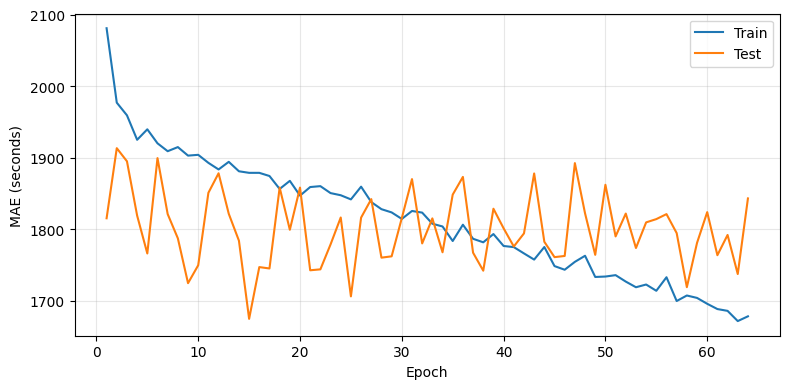

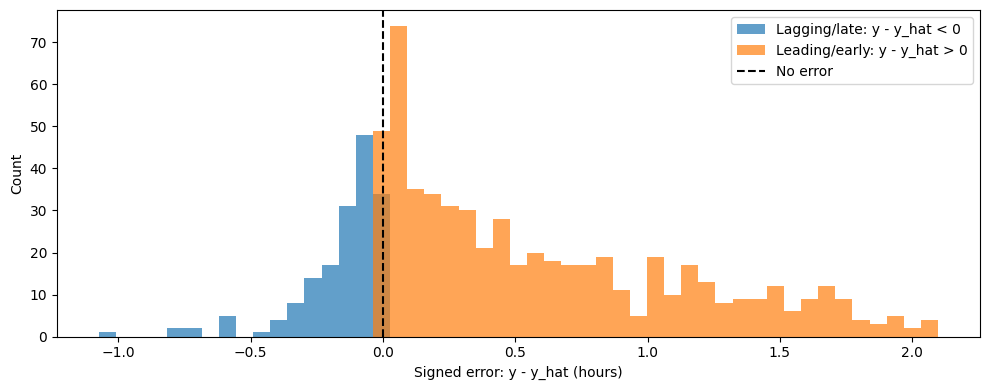

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(
    asymmetric_history["epoch"],
    asymmetric_history["train_mae_seconds"],
    label="Train",
)
plt.plot(
    asymmetric_history["epoch"],
    asymmetric_history["test_mae_seconds"],
    label="Test",
)
plt.xlabel("Epoch")
plt.ylabel("MAE (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / "asymmetric_training_mae.pdf", dpi=300)
plt.show()

weighted_signed_errors_hours = asymmetric_predictions["signed_error"] / SECONDS_PER_HOUR
weighted_leading_errors_hours = weighted_signed_errors_hours[
    weighted_signed_errors_hours > 0
]
weighted_lagging_errors_hours = weighted_signed_errors_hours[
    weighted_signed_errors_hours < 0
]
weighted_signed_error_bins_hours = np.linspace(
    weighted_signed_errors_hours.min(),
    weighted_signed_errors_hours.max(),
    50,
)

plt.figure(figsize=(10, 4))
plt.hist(
    weighted_lagging_errors_hours,
    bins=weighted_signed_error_bins_hours,
    alpha=0.7,
    label="Lagging/late: y - y_hat < 0",
)
plt.hist(
    weighted_leading_errors_hours,
    bins=weighted_signed_error_bins_hours,
    alpha=0.7,
    label="Leading/early: y - y_hat > 0",
)
plt.axvline(0, color="black", linestyle="--", label="No error")
plt.xlabel("Signed error: y - y_hat (hours)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(
    MODEL_OUTPUT_DIR / "asymmetric_transformer_signed_error_distribution.pdf",
    dpi=300,
)
plt.show()

## Comparison report

In [12]:
comparison_summary = pd.DataFrame(
    [
        {"model": "Baseline MAE", **baseline_metrics},
        {"model": "Asymmetric MAE", **asymmetric_metrics},
    ]
)
comparison_summary.to_csv(
    MODEL_OUTPUT_DIR / REGRESSION_SUMMARY_FILENAME,
    index=False,
)

model_configuration = {
    "window_hours": WINDOW_HOURS,
    "window_search_performed": False,
    "when_dataset_path": str(WHEN_DATASET_PATH),
    "sequence_dataset_path": str(SEQUENCE_DATASET_PATH),
    "train_folds": TRAIN_FOLDS,
    "test_fold": TEST_FOLD,
    "random_state": RANDOM_STATE,
    "device": str(DEVICE),
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "zone_embedding_dim": ZONE_EMBEDDING_DIM,
    "outage_type_embedding_dim": OUTAGE_TYPE_EMBEDDING_DIM,
    "time_interval_embedding_dim": TIME_INTERVAL_EMBEDDING_DIM,
    "transformer_dim": TRANSFORMER_DIM,
    "dropout": DROPOUT,
    "leading_prediction_penalty": LEADING_PREDICTION_PENALTY,
    "lagging_prediction_penalty": LAGGING_PREDICTION_PENALTY,
}
(MODEL_OUTPUT_DIR / "model_configuration.json").write_text(
    json.dumps(model_configuration, indent=4)
)

display(
    comparison_summary[
        [
            "model",
            "mae",
            "middle_50_mae",
            "rmse",
            "r2",
            "asymmetric_penalized_mae",
            "leading_prediction_rate",
            "lagging_prediction_rate",
        ]
    ]
)

print(
    "Baseline middle-50% MAE: "
    f"{baseline_metrics['middle_50_mae']:.6f} seconds "
    f"({baseline_metrics['middle_50_mae'] / 60:.6f} minutes)"
)
print(
    "Asymmetric middle-50% MAE: "
    f"{asymmetric_metrics['middle_50_mae']:.6f} seconds "
    f"({asymmetric_metrics['middle_50_mae'] / 60:.6f} minutes)"
)
print(
    "Baseline lagging prediction rate: "
    f"{baseline_metrics['lagging_prediction_rate']:.6%}"
)
print(
    "Asymmetric lagging prediction rate: "
    f"{asymmetric_metrics['lagging_prediction_rate']:.6%}"
)
print(f"Saved all reports and plots under {MODEL_OUTPUT_DIR}")

,model,mae,middle_50_mae,rmse,r2,asymmetric_penalized_mae,leading_prediction_rate,lagging_prediction_rate
0,Baseline MAE,1714.912109,1350.931641,2272.935437,-0.170619,2949.378418,0.494624,0.505376
1,Asymmetric MAE,1843.072021,1254.954102,2648.121504,-0.588976,2099.860107,0.775538,0.224462


Baseline middle-50% MAE: 1350.931641 seconds (22.515527 minutes)
Asymmetric middle-50% MAE: 1254.954102 seconds (20.915902 minutes)
Baseline lagging prediction rate: 50.537634%
Asymmetric lagging prediction rate: 22.446237%
Saved all reports and plots under model_outputs/transformer_when
